Paquetes necesarios

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Hay 7 filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: [6, 12, 15, 20, 21, 88, 100]


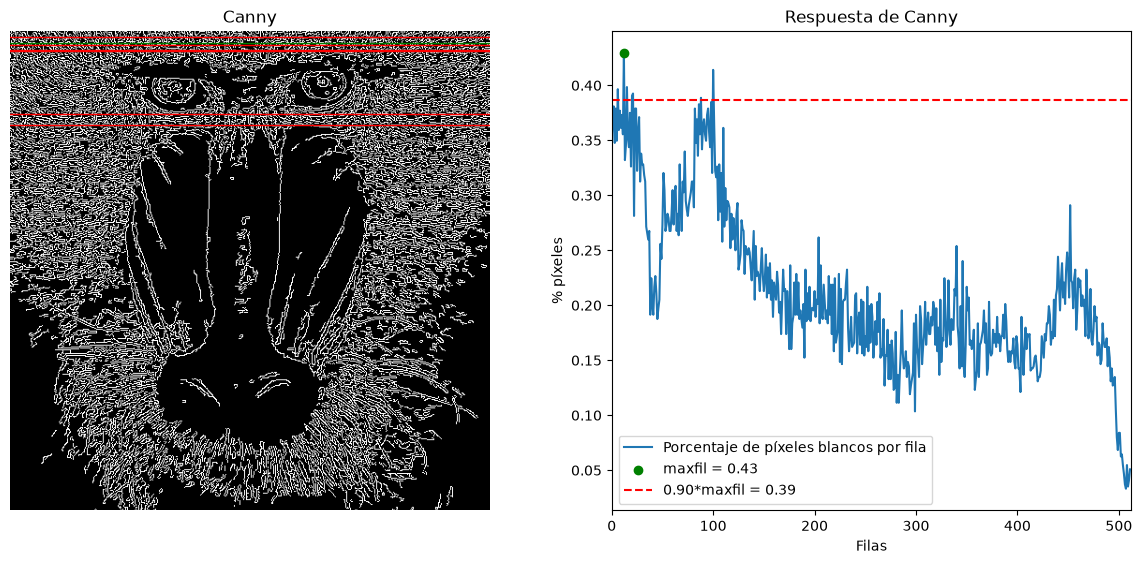

In [2]:
# Leemos la imagen del archivo
img = cv2.imread('images/mandril.jpg')

# Si hay lectura correcta
if img is not None:
    # Conversión de la imagen a niveles de grises de la imagen original en BGR
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Obtenemos los contornos con el operador de Canny
    canny = cv2.Canny(gris, 100, 200)

    # Contamos el número de píxeles blancos (255) por fila
    # Sumamos los valores de los pixeles por fila
    row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
    row_counts = row_counts.flatten()  # Aplanamos el array para que sea unidimensional

    # Normalizamos en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
    # El resultado será el número de píxeles blancos por fila
    rows = row_counts / (255 * canny.shape[1])

    # Obtenemos el valor máximo de píxeles blancos para filas
    maxfil = rows.max()

    # Obtenemos el índice de la fila con el máximo número de píxeles blancos
    idx_maxfil = np.where(rows == maxfil)[0][0]  

    # Creamos una lista para almacenar los índices de las filas que cumplen el umbral
    idx_rows_threshold = []

    # Mostramos dicha cuenta gráficamente
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("Canny")
    for i in range(len(rows)):
        if rows[i] >= maxfil*0.9:
            idx_rows_threshold.append(i)                                 # Añadimos el índice de la fila que cumple el umbral a la lista

            if i == idx_maxfil: 
                plt.axhline(y=i, color='g', linestyle='-', linewidth=1)  # Mostramos la fila con el máximo número de píxeles blancos
            else:
                plt.axhline(y=i, color='r', linestyle='-', linewidth=1)  # Mostramos las filas que superan el 90% del valor máximo
    plt.imshow(canny, cmap='gray')

    # Calculamos el umbral como el 90% del valor máximo de píxeles blancos por fila
    umbral = maxfil * 0.9  

    plt.subplot(1, 2, 2)
    plt.title("Respuesta de Canny")
    plt.xlabel("Filas")
    plt.ylabel("% píxeles")
    plt.plot(rows, label='Porcentaje de píxeles blancos por fila')
    plt.scatter(idx_maxfil, maxfil, color='g', zorder=5, label=f'maxfil = {maxfil:.2f}')  # Marcamos el máximo con un punto verde
    plt.axhline(y=umbral, color='r', linestyle='--', label=f'0.90*maxfil = {umbral:.2f}')  # Línea horizontal para el umbral
    # Rango en x definido por las filas
    plt.xlim([0, canny.shape[0]])
    plt.legend()
    plt.tight_layout(pad=2.0, w_pad=3.0) # Ajustamos el espaciado entre subplots

    print(f"Hay {len(idx_rows_threshold)} filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: {idx_rows_threshold}")

else: 
    print('Imagen no encontrada')

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.